## Algorithms

### Capacitated Vehicle Routing Problem (CVRP):

ACO version for solving the Capacitated Vehicle Routing Problem (CVRP)

Basic modular code for AOC

In [52]:
import math
import random

# Modular design for the basic ACO model (function-based)

# Distance matrix
def build_distance_matrix(instance):
    nodes = [instance["depot"]] + [(c[0], c[1]) for c in instance["customers"]]
    n = len(nodes)
    matrix = [[0.0] * n for _ in range(n)]
    
    for i in range(n):
        for j in range(n):
            matrix[i][j] = math.dist(nodes[i], nodes[j])
    return matrix

# Pheromone matrix helpers
def init_pheromone_matrix(size: int, initial_value: float):
    return [[initial_value] * size for _ in range(size)]

def evaporate_pheromones(pheromones, evaporation_rate: float):
    for i in range(len(pheromones)):
        for j in range(len(pheromones)):
            pheromones[i][j] *= (1 - evaporation_rate)

def deposit_pheromones(pheromones, solution, cost, Q=100):
    deposit_amount = Q / cost
    for route in solution:
        for i in range(len(route) - 1):
            a, b = route[i], route[i + 1]
            pheromones[a][b] += deposit_amount
            pheromones[b][a] += deposit_amount

# CVRP ant construction (generic, function-based)
def construct_solution_cvrp(instance, dist_matrix, pheromones, alpha, beta):
    unvisited = set(range(1, instance["num_customers"] + 1))
    solution = []

    while unvisited:
        route = [0]
        load = 0.0
        current = 0

        while True:
            feasible = [
                c for c in unvisited
                if load + instance["customers"][c - 1][2] <= instance["capacity"]
            ]

            if not feasible:
                break

            next_node = select_next_cvrp(current, feasible, dist_matrix, pheromones, alpha, beta)
            route.append(next_node)

            load += instance["customers"][next_node - 1][2]
            unvisited.remove(next_node)
            current = next_node

        route.append(0)
        solution.append(route)

    return solution

# Probabilistic selection for CVRP
def select_next_cvrp(current, candidates, dist_matrix, pheromones, alpha, beta):
    probabilities = []
    total = 0.0

    for j in candidates:
        tau = pheromones[current][j] ** alpha
        eta = (1 / dist_matrix[current][j]) ** beta
        value = tau * eta
        probabilities.append((j, value))
        total += value

    if total <= 0.0:
        return random.choice(candidates)

    r = random.random() * total
    cumulative = 0.0

    for node, prob in probabilities:
        cumulative += prob
        if cumulative >= r:
            return node

    return probabilities[-1][0]

# Cost evaluation, compute the cost as total distance
def compute_cost(solution, dist_matrix):
    total = 0.0
    for route in solution:
        for i in range(len(route) - 1):
            total += dist_matrix[route[i]][route[i + 1]]
    return total


Module specific implementation for the CVRP

In [53]:
import math
import random
from typing import List, Tuple # for readability in function declarations 

# Specific implementation module for the CVRP problem
# Reuses most of implementation from the basic module

# Parser file for benchmark inputs, specific for the CVRP test file
def parse_cvrp_input(file_path):
    with open(file_path) as f:
        lines = f.readlines()

    capacity = float(lines[0].strip())
    depot = tuple(map(float, lines[1].split()))
    customers = [tuple(map(float, line.split())) for line in lines[2:]]

    return {
        "capacity": capacity,
        "depot": depot,
        "customers": customers,
        "num_customers": len(customers),
    }

# ACO solver for CVRP (function-based)
def solve_aco_cvrp(instance,
                   num_ants=20,
                   iterations=100,
                   alpha=1,
                   beta=2,
                   rho=0.1,
                   return_history=False):
    dist_matrix = build_distance_matrix(instance)
    pheromones = init_pheromone_matrix(len(dist_matrix), 1.0)

    best_solution = None
    best_cost = float("inf")
    history = []

    for _ in range(iterations):
        all_solutions = []

        for _ in range(num_ants):
            solution = construct_solution_cvrp(
                instance, dist_matrix, pheromones, alpha, beta
            )
            cost = compute_cost(solution, dist_matrix)
            all_solutions.append((solution, cost))

            if cost < best_cost:
                best_solution = solution
                best_cost = cost

        evaporate_pheromones(pheromones, rho)
        for solution, cost in all_solutions:
            deposit_pheromones(pheromones, solution, cost)

        history.append(best_cost)

    if return_history:
        return best_solution, best_cost, history
    return best_solution, best_cost
    
def main():
    instance = parse_cvrp_input("cvrp.txt")
    solution, cost = solve_aco_cvrp(instance)

    print("Best cost:", cost)
    print("Routes:", solution)


if __name__ == "__main__":
    main()

Best cost: 634.5339110913039
Routes: [[0, 46, 12, 47, 4, 18, 25, 14, 0], [0, 5, 38, 11, 16, 50, 34, 21, 29, 2, 22, 0], [0, 27, 48, 6, 23, 7, 43, 24, 13, 41, 40, 0], [0, 17, 37, 44, 42, 19, 33, 45, 15, 49, 9, 30, 39, 10, 0], [0, 32, 1, 8, 26, 31, 28, 3, 20, 35, 36, 0]]


GRASP Baseline method

Basic module for GRASP

In [54]:
import math
import random
from typing import List, Tuple, Callable

# ── 1. Cost Evaluation ────────────────────────────────────────────────────────
# Identical to ACO_basic.compute_cost — importable from there directly.

def compute_cost(solution: List[List[int]],
                 dist_matrix: List[List[float]]) -> float:
    total = 0.0
    for route in solution:
        for i in range(len(route) - 1):
            total += dist_matrix[route[i]][route[i + 1]]
    return total


# ── 2. Greedy Randomised Construction ────────────────────────────────────────

def greedy_randomised_construction(instance,
                                   dist_matrix: List[List[float]],
                                   alpha: float,
                                   feasibility_fn: Callable,
                                   score_fn: Callable,
                                   init_state_fn: Callable,
                                   update_state_fn: Callable) -> List[List[int]]:
    """
    Generic GRASP construction phase.

    Parameters
    ----------
    instance        : problem instance (CVRP or VRPTW)
    dist_matrix     : precomputed distance matrix
    alpha           : RCL threshold in [0, 1]
    feasibility_fn  : (candidate, current, route_state, dist_matrix) -> bool
                      True if visiting candidate next is feasible.
    score_fn        : (candidate, current, route_state, dist_matrix) -> float
                      Lower = more desirable (e.g. distance, urgency).
    init_state_fn   : (instance) -> dict
                      Returns a fresh route state at the start of each route.
                      CVRP: {"load": 0}   VRPTW: {"load": 0, "time": 0}
    update_state_fn : (node, state, instance, dist_matrix, previous) -> None
                      Mutates route state after committing to a node.

    Returns
    -------
    A complete solution: list of routes, each starting and ending at 0.
    """
    unvisited = set(range(1, instance["num_customers"] + 1))
    solution  = []

    while unvisited:
        route       = [0]
        route_state = init_state_fn(instance)
        current     = 0

        while True:
            feasible = [c for c in unvisited
                        if feasibility_fn(c, current, route_state, dist_matrix)]

            if not feasible:
                break

            scores    = {c: score_fn(c, current, route_state, dist_matrix)
                         for c in feasible}
            c_min     = min(scores.values())
            c_max     = max(scores.values())
            threshold = c_min + alpha * (c_max - c_min)

            rcl       = [c for c, s in scores.items() if s <= threshold]
            next_node = random.choice(rcl)

            route.append(next_node)
            unvisited.remove(next_node)
            update_state_fn(next_node, route_state, instance, dist_matrix, current)
            current = next_node

        route.append(0)
        solution.append(route)

    return solution


# ── 3. 2-opt Local Search ─────────────────────────────────────────────────────

def two_opt(route: List[int],
            dist_matrix: List[List[float]],
            feasibility_check: Callable = None) -> List[int]:
    """
    Standard 2-opt improvement for a single route.

    Iteratively reverses segments until no improving swap exists
    (first-improvement strategy).

    Parameters
    ----------
    route             : single route including depot at both ends
    dist_matrix       : precomputed distance matrix
    feasibility_check : optional callable(new_route) -> bool
                        Rejects swaps that violate constraints (e.g. VRPTW
                        time windows). If None all improving swaps are accepted.
    """
    best     = route[:]
    improved = True

    while improved:
        improved = False
        for i in range(1, len(best) - 2):
            for j in range(i + 1, len(best) - 1):
                delta = (
                    dist_matrix[best[i - 1]][best[j]]
                    + dist_matrix[best[i]][best[j + 1]]
                    - dist_matrix[best[i - 1]][best[i]]
                    - dist_matrix[best[j]][best[j + 1]]
                )
                if delta < -1e-10:
                    candidate = best[:i] + best[i:j + 1][::-1] + best[j + 1:]
                    if feasibility_check is None or feasibility_check(candidate):
                        best     = candidate
                        improved = True

    return best


def local_search(solution: List[List[int]],
                 dist_matrix: List[List[float]],
                 feasibility_check: Callable = None) -> List[List[int]]:
    """Apply 2-opt independently to every route in the solution."""
    return [two_opt(route, dist_matrix, feasibility_check)
            for route in solution]


# ── 4. Main GRASP Loop ────────────────────────────────────────────────────────

def grasp(instance,
          dist_matrix:          List[List[float]],
          iterations:           int,
          alpha:                float,
          feasibility_fn:       Callable,
          score_fn:             Callable,
          init_state_fn:        Callable,
          update_state_fn:      Callable,
          cost_fn:              Callable = None,
          feasibility_check_2opt: Callable = None,
          return_history: bool = False) -> Tuple[List[List[int]], float]:
    """
    Core GRASP loop shared by CVRP and VRPTW solvers.

    Parameters
    ----------
    instance               : problem instance
    dist_matrix            : precomputed distance matrix
    iterations             : number of GRASP iterations
    alpha                  : RCL greediness parameter ∈ [0, 1]
    feasibility_fn         : passed to greedy_randomised_construction
    score_fn               : passed to greedy_randomised_construction
    init_state_fn          : passed to greedy_randomised_construction
    update_state_fn        : passed to greedy_randomised_construction
    cost_fn                : callable(solution) -> float
                             Defaults to total distance if not provided.
                             Pass a custom function to add e.g. fleet penalty.
    feasibility_check_2opt : optional callable(route) -> bool passed to two_opt
    return_history         : when True returns a list of best costs per iteration

    Returns
    -------
    (best_solution, best_cost)
    """
    if cost_fn is None:
        cost_fn = lambda sol: compute_cost(sol, dist_matrix)

    best_solution = None
    best_cost     = math.inf
    history = []

    for iteration in range(iterations):
        # Phase 1: greedy randomised construction
        solution = greedy_randomised_construction(
            instance, dist_matrix, alpha,
            feasibility_fn, score_fn,
            init_state_fn, update_state_fn
        )

        # Phase 2: 2-opt local search
        solution = local_search(solution, dist_matrix, feasibility_check_2opt)

        cost = cost_fn(solution)

        if cost < best_cost:
            best_solution = solution
            best_cost     = cost

        history.append(best_cost)

        if (iteration + 1) % 10 == 0:
            print(f"  Iteration {iteration+1:4d} | best cost: {best_cost:.2f}")

    if return_history:
        return best_solution, best_cost, history
    return best_solution, best_cost

GRASP module specific implementation for the CVRP 

In [55]:
from typing import List, Tuple

# ── Route state ───────────────────────────────────────────────────────────────

def cvrp_init_state(instance) -> dict:
    return {"load": 0.0}


def cvrp_update_state(node, state, instance, dist_matrix, previous) -> None:
    state["load"] += instance["customers"][node - 1][2]   # demand at index 2


# ── Feasibility and scoring ───────────────────────────────────────────────────

def cvrp_feasibility_fn(candidate, current, route_state, dist_matrix) -> bool:
    instance = route_state["instance"]
    demand   = instance["customers"][candidate - 1][2]
    return route_state["load"] + demand <= instance["capacity"]


def cvrp_score_fn(candidate, current, route_state, dist_matrix) -> float:
    """Score = distance from current node to candidate (lower = better)."""
    return dist_matrix[current][candidate]


# ── Solver ────────────────────────────────────────────────────────────────────

def solve_grasp_cvrp(instance, iterations: int = 100, alpha: float = 0.3, return_history: bool = False):
    dist_matrix = build_distance_matrix(instance)

    # Inject instance into route state via closure so feasibility_fn
    # can access it without it being a global
    def _init_state(inst):
        return {"load": 0.0, "instance": inst}

    return grasp(
        instance,
        dist_matrix,
        iterations,
        alpha,
        feasibility_fn=cvrp_feasibility_fn,
        score_fn=cvrp_score_fn,
        init_state_fn=_init_state,
        update_state_fn=cvrp_update_state,
        return_history=return_history,
    )


# ── Entry point ───────────────────────────────────────────────────────────────

def main():
    instance = parse_cvrp_input("cvrp.txt")

    print(f"Loaded: {instance['num_customers']} customers, "
          f"capacity={instance['capacity']}\n")

    solution, cost = solve_grasp_cvrp(instance, iterations=100, alpha=0.3)

    print(f"\nBest cost : {cost:.4f}")
    print(f"Vehicles  : {len(solution)}")
    print("\nRoutes:")
    for i, route in enumerate(solution):
        print(f"  Vehicle {i+1}: {route}")


if __name__ == "__main__":
    main()

Loaded: 50 customers, capacity=160.0

  Iteration   10 | best cost: 675.66
  Iteration   20 | best cost: 675.66
  Iteration   30 | best cost: 670.83
  Iteration   40 | best cost: 670.83
  Iteration   50 | best cost: 670.83
  Iteration   60 | best cost: 670.83
  Iteration   70 | best cost: 656.48
  Iteration   80 | best cost: 656.48
  Iteration   90 | best cost: 656.48
  Iteration  100 | best cost: 656.48

Best cost : 656.4763
Vehicles  : 5

Routes:
  Vehicle 1: [0, 46, 11, 30, 39, 10, 45, 15, 44, 17, 47, 12, 0]
  Vehicle 2: [0, 5, 33, 49, 9, 16, 2, 22, 1, 32, 27, 0]
  Vehicle 3: [0, 19, 40, 41, 13, 18, 14, 6, 48, 0]
  Vehicle 4: [0, 8, 26, 7, 23, 43, 24, 25, 4, 42, 37, 38, 0]
  Vehicle 5: [0, 50, 34, 21, 29, 20, 35, 36, 3, 28, 31, 0]


### Vehicle Routing Problem with Time Windows (VRPTW)

In [56]:
import math
import random
from typing import List, Tuple # for readability in function declarations

# ACO module for the VRPTW 
# Some functions reused from the ACO basic module, this module consists of problem specific implementations

EPSILON = 1e-6 # Used to avoid dividing by zero
PENALTY_FACTOR = 1000 # Used to compute penalty

# Parser file for benchmark inputs, specific for the VRPTW test file
def parse_vrptw_input(file_path: str):
    with open(file_path) as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    num_vehicles = int(lines[0].split()[0])
    capacity     = float(lines[0].split()[1])
    depot        = tuple(map(float, lines[1].split()))
    customers    = [tuple(map(float, ln.split())) for ln in lines[2:]]

    return {
        "num_vehicles": num_vehicles,
        "capacity": capacity,
        "depot": depot,
        "customers": customers,
        "num_customers": len(customers),
    }

# VRPTW construction helpers
def is_feasible_vrptw(instance, dist_matrix, c, current, current_time, load) -> bool:
    demand = instance["customers"][c - 1][2]
    if load + demand > instance["capacity"]:
        return False

    travel  = dist_matrix[current][c]
    arrival = current_time + travel
    close   = instance["customers"][c - 1][4]
    return arrival <= close


def select_next_vrptw(instance, dist_matrix, pheromones, current, current_time, candidates, alpha, beta, gamma) -> int:
    probabilities = []
    total = 0.0

    for j in candidates:
        travel  = dist_matrix[current][j]
        arrival = current_time + travel
        close   = instance["customers"][j - 1][4]

        tau  = pheromones[current][j] ** alpha
        eta1 = (1.0 / travel) ** beta

        slack = close - arrival
        eta2  = (1.0 / (slack + EPSILON)) ** gamma

        value = tau * eta1 * eta2
        probabilities.append((j, value))
        total += value

    if total <= 0.0:
        return random.choice(candidates)

    r = random.random() * total
    cumulative = 0.0

    for node, prob in probabilities:
        cumulative += prob
        if cumulative >= r:
            return node

    return probabilities[-1][0]


def construct_solution_vrptw(instance, dist_matrix, pheromones, alpha, beta, gamma):
    unvisited = set(range(1, instance["num_customers"] + 1))
    solution = []

    while unvisited:
        route        = [0]
        load         = 0.0
        current      = 0
        current_time = 0.0

        while True:
            feasible = [
                c for c in unvisited
                if is_feasible_vrptw(instance, dist_matrix, c, current, current_time, load)
            ]

            if not feasible:
                break

            next_node = select_next_vrptw(
                instance, dist_matrix, pheromones,
                current, current_time, feasible,
                alpha, beta, gamma,
            )

            travel       = dist_matrix[current][next_node]
            arrival      = current_time + travel
            open_t       = instance["customers"][next_node - 1][3]
            service_time = instance["customers"][next_node - 1][5]
            current_time = max(arrival, open_t) + service_time
            
            load += instance["customers"][next_node - 1][2]
            route.append(next_node)
            unvisited.remove(next_node)
            current = next_node

        route.append(0)
        solution.append(route)

    return solution

# ACO solver for VRPTW (function-based)
def solve_aco_vrptw(instance,
                    num_ants:   int   = 20,
                    iterations: int   = 100,
                    alpha:      float = 1.0,
                    beta:       float = 2.0,
                    gamma:      float = 1.5,
                    rho:        float = 0.1,
                    Q:          float = 100.0,
                    return_history: bool = False):
    dist_matrix = build_distance_matrix(instance)
    pheromones  = init_pheromone_matrix(len(dist_matrix), 1.0)

    best_solution = None
    best_cost     = math.inf
    history = []

    for iteration in range(iterations):
        all_solutions = []

        for _ in range(num_ants):
            solution = construct_solution_vrptw(
                instance, dist_matrix, pheromones, alpha, beta, gamma
            )
            cost = compute_cost(solution, dist_matrix)
            s = max(0, len(solution) - instance["num_vehicles"])
            penalised_cost = cost + s * PENALTY_FACTOR
            all_solutions.append((solution, penalised_cost))

            if penalised_cost < best_cost:
                best_solution = solution
                best_cost     = penalised_cost

        evaporate_pheromones(pheromones, rho)
        for solution, cost in all_solutions:
            deposit_pheromones(pheromones, solution, cost, Q=Q)

        history.append(best_cost)

        if (iteration + 1) % 10 == 0:
            print(f"  Iteration {iteration+1:4d} | best cost: {best_cost:.2f}")

    if len(best_solution) > instance["num_vehicles"]:
        print(f"\n  Solution uses {len(best_solution)} vehicles "
              f"but instance allows {instance['num_vehicles']}.")

    if return_history:
        return best_solution, best_cost, history
    return best_solution, best_cost


def main():
    instance = parse_vrptw_input("vrptw.txt")

    print(f"Loaded: {instance['num_customers']} customers | "
          f"{instance['num_vehicles']} vehicles | capacity={instance['capacity']}\n")

    solution, cost = solve_aco_vrptw(
        instance, num_ants=30, iterations=100,
        alpha=1.0, beta=2.0, gamma=1.5, rho=0.1
    )

    print(f"\nBest cost : {cost:.4f}")
    print(f"Vehicles  : {len(solution)}")
    print("\nRoutes:")
    for i, route in enumerate(solution):
        print(f"  Vehicle {i+1}: {route}")


if __name__ == "__main__":
    main()

Loaded: 100 customers | 25 vehicles | capacity=200.0

  Iteration   10 | best cost: 2485.71
  Iteration   20 | best cost: 2458.49
  Iteration   30 | best cost: 2346.66
  Iteration   40 | best cost: 2315.33
  Iteration   50 | best cost: 2315.33
  Iteration   60 | best cost: 2315.33
  Iteration   70 | best cost: 2315.33
  Iteration   80 | best cost: 2227.71
  Iteration   90 | best cost: 2227.71
  Iteration  100 | best cost: 2227.71

Best cost : 2227.7143
Vehicles  : 25

Routes:
  Vehicle 1: [0, 14, 44, 38, 96, 13, 89, 58, 0]
  Vehicle 2: [0, 59, 42, 98, 61, 85, 37, 91, 100, 0]
  Vehicle 3: [0, 36, 47, 19, 8, 46, 48, 0]
  Vehicle 4: [0, 72, 75, 73, 22, 74, 25, 0]
  Vehicle 5: [0, 5, 52, 99, 94, 97, 60, 93, 0]
  Vehicle 6: [0, 63, 62, 11, 90, 50, 1, 80, 0]
  Vehicle 7: [0, 4, 77, 0]
  Vehicle 8: [0, 27, 31, 88, 7, 10, 32, 70, 0]
  Vehicle 9: [0, 30, 79, 34, 35, 0]
  Vehicle 10: [0, 92, 95, 15, 84, 17, 0]
  Vehicle 11: [0, 53, 26, 24, 0]
  Vehicle 12: [0, 87, 57, 43, 0]
  Vehicle 13: [0, 65

GRASP baseline implementation for VRPTW

In [57]:
from typing import List, Tuple

# GRASP_VRPTW.py
#
# GRASP solver for the Vehicle Routing Problem with Time Windows.
# Reuses the shared GRASP loop, construction, and 2-opt from GRASP_basic.
# Reuses DistanceMatrix from ACO_basic. Time-window helpers are inlined below.
#
# Supplies four problem-specific callables to GRASP_basic:
#   init_state_fn          - route state needs both load and current time
#   update_state_fn        - advance load and clock after each visit
#   feasibility_fn         - capacity + time window reachability
#   score_fn               - distance + slack urgency (mirrors ACO eta1*eta2)
#
# Also supplies:
#   cost_fn                - total distance + fleet-size penalty
#   feasibility_check_2opt - reject 2-opt swaps that violate time windows

EPSILON = 1e-6

# Time-window helpers (inlined - trivial enough not to warrant a separate import)
def service_start_time(arrival, customer):
    _, _, _, open_t, close_t, _ = customer
    if arrival > close_t:
        return None
    return max(arrival, open_t)

def compute_slack(current_time, travel_time, customer):
    _, _, _, _, close_t, _ = customer
    return close_t - (current_time + travel_time)

# Route state
def vrptw_init_state(instance) -> dict:
    return {"load": 0.0, "time": 0.0}

def vrptw_update_state(node, state, instance, dist_matrix, previous) -> None:
    cust    = instance["customers"][node - 1]
    travel  = dist_matrix[previous][node]
    arrival = state["time"] + travel
    start   = service_start_time(arrival, cust)
    state["time"] = start + cust[5]   # service_time at index 5
    state["load"] += cust[2]          # demand at index 2

# Feasibility and scoring
def vrptw_feasibility_fn(candidate, current, route_state, dist_matrix) -> bool:
    """Feasible if capacity not exceeded AND time window can still be reached."""
    instance = route_state["instance"]
    cust     = instance["customers"][candidate - 1]
    travel   = dist_matrix[current][candidate]

    if route_state["load"] + cust[2] > instance["capacity"]:
        return False

    arrival = route_state["time"] + travel
    return service_start_time(arrival, cust) is not None

def vrptw_score_fn(candidate, current, route_state, dist_matrix) -> float:
    """
    Score = distance + w * slack  (lower = better).
    Short distance and tight deadlines both push the score down,
    mirroring the eta1 * eta2 heuristic terms from ACO_VRPTW.
    """
    instance = route_state["instance"]
    cust     = instance["customers"][candidate - 1]
    travel   = dist_matrix[current][candidate]
    slack    = compute_slack(route_state["time"], travel, cust)

    w = 0.5   # relative weight of urgency vs distance - tunable
    return travel + w * slack

# 2-opt feasibility check
def route_time_feasible(route: List[int],
                        instance,
                        dist_matrix: List[List[float]]) -> bool:
    """True if all time windows are respected along the route."""
    time = 0.0
    for i in range(len(route) - 1):
        a, b = route[i], route[i + 1]
        if b == 0:
            break
        travel  = dist_matrix[a][b]
        cust    = instance["customers"][b - 1]
        arrival = time + travel
        start   = service_start_time(arrival, cust)
        if start is None:
            return False
        time = start + cust[5]
    return True

# Solver
def solve_grasp_vrptw(instance, iterations: int = 100, alpha: float = 0.3, return_history: bool = False):
    dist_matrix = build_distance_matrix(instance)

    def _init_state(inst):
        return {"load": 0.0, "time": 0.0, "instance": inst}

    def _cost_fn(solution):
        base   = compute_cost(solution, dist_matrix)
        excess = max(0, len(solution) - instance["num_vehicles"])
        return base + excess * PENALTY_FACTOR

    def _feasibility_check_2opt(route):
        return route_time_feasible(route, instance, dist_matrix)

    return grasp(
        instance,
        dist_matrix,
        iterations,
        alpha,
        feasibility_fn=vrptw_feasibility_fn,
        score_fn=vrptw_score_fn,
        init_state_fn=_init_state,
        update_state_fn=vrptw_update_state,
        cost_fn=_cost_fn,
        feasibility_check_2opt=_feasibility_check_2opt,
        return_history=return_history,
    )

# Entry point
def main():
    instance = parse_vrptw_input("vrptw.txt")

    print(f"Loaded: {instance['num_customers']} customers, "
          f"{instance['num_vehicles']} vehicles, capacity={instance['capacity']}\n")

    solution, cost = solve_grasp_vrptw(instance, iterations=100, alpha=0.3)

    print(f"\nBest cost : {cost:.4f}")
    print(f"Vehicles  : {len(solution)}")
    print("\nRoutes:")
    for i, route in enumerate(solution):
        print(f"  Vehicle {i+1}: {route}")


if __name__ == "__main__":
    main()

Loaded: 100 customers, 25 vehicles, capacity=200.0

  Iteration   10 | best cost: 2396.81
  Iteration   20 | best cost: 2396.81
  Iteration   30 | best cost: 2396.81
  Iteration   40 | best cost: 2396.81
  Iteration   50 | best cost: 2375.91
  Iteration   60 | best cost: 2375.91
  Iteration   70 | best cost: 2375.91
  Iteration   80 | best cost: 2375.91
  Iteration   90 | best cost: 2375.91
  Iteration  100 | best cost: 2375.91

Best cost : 2375.9142
Vehicles  : 25

Routes:
  Vehicle 1: [0, 98, 8, 96, 60, 89, 58, 0]
  Vehicle 2: [0, 14, 40, 57, 43, 13, 100, 0]
  Vehicle 3: [0, 92, 31, 53, 37, 17, 93, 0]
  Vehicle 4: [0, 69, 78, 50, 68, 80, 0]
  Vehicle 5: [0, 62, 88, 7, 20, 32, 70, 0]
  Vehicle 6: [0, 36, 47, 19, 49, 48, 0]
  Vehicle 7: [0, 28, 51, 34, 35, 77, 0]
  Vehicle 8: [0, 42, 61, 85, 91, 0]
  Vehicle 9: [0, 95, 16, 94, 26, 4, 25, 0]
  Vehicle 10: [0, 82, 90, 66, 1, 0]
  Vehicle 11: [0, 27, 52, 79, 3, 54, 24, 0]
  Vehicle 12: [0, 63, 64, 46, 0]
  Vehicle 13: [0, 72, 75, 73, 22, 

## Visualizations
### CVRP (ACO + GRASP)

  Iteration   10 | best cost: 684.33
  Iteration   20 | best cost: 684.33
  Iteration   30 | best cost: 684.33
  Iteration   40 | best cost: 684.33
  Iteration   50 | best cost: 684.33
  Iteration   60 | best cost: 684.33
  Iteration   70 | best cost: 684.33
  Iteration   80 | best cost: 684.33
  Iteration   90 | best cost: 684.33
  Iteration  100 | best cost: 656.36


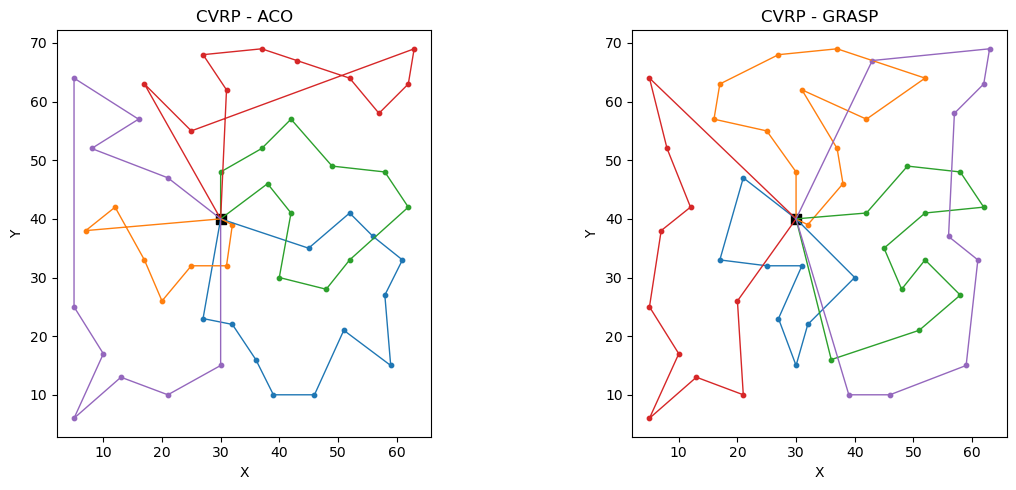

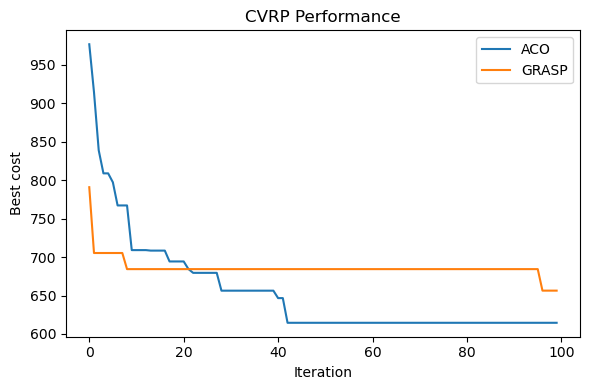

In [58]:
import matplotlib.pyplot as plt

def plot_routes(ax, instance, solution, title):
    depot_x, depot_y = instance["depot"]
    ax.scatter([depot_x], [depot_y], c="black", s=60, marker="s", label="Depot")

    for route in solution:
        xs = [depot_x]
        ys = [depot_y]
        for node in route:
            if node == 0:
                continue
            x, y = instance["customers"][node - 1][0], instance["customers"][node - 1][1]
            xs.append(x)
            ys.append(y)
        xs.append(depot_x)
        ys.append(depot_y)
        ax.plot(xs, ys, linewidth=1.0)
        ax.scatter(xs[1:-1], ys[1:-1], s=10)

    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

# Fix randomness for comparable plots
random.seed(42)

# CVRP ACO
cvrp_instance = parse_cvrp_input("cvrp.txt")
cvrp_aco_solution, _, cvrp_aco_history = solve_aco_cvrp(
    cvrp_instance, return_history=True
 )

# CVRP GRASP
cvrp_grasp_solution, _, cvrp_grasp_history = solve_grasp_cvrp(
    cvrp_instance, iterations=100, alpha=0.3, return_history=True
 )

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_routes(axes[0], cvrp_instance, cvrp_aco_solution, "CVRP - ACO")
plot_routes(axes[1], cvrp_instance, cvrp_grasp_solution, "CVRP - GRASP")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(cvrp_aco_history, label="ACO")
ax.plot(cvrp_grasp_history, label="GRASP")
ax.set_title("CVRP Performance")
ax.set_xlabel("Iteration")
ax.set_ylabel("Best cost")
ax.legend()
plt.tight_layout()
plt.show()

### VRPTW (ACO + GRASP)

  Iteration   10 | best cost: 3508.95
  Iteration   20 | best cost: 2313.40
  Iteration   30 | best cost: 2313.40
  Iteration   40 | best cost: 2313.40
  Iteration   50 | best cost: 2313.40
  Iteration   60 | best cost: 2313.40
  Iteration   70 | best cost: 2313.40
  Iteration   80 | best cost: 2313.40
  Iteration   90 | best cost: 2313.40
  Iteration  100 | best cost: 2313.40
  Iteration   10 | best cost: 3511.65
  Iteration   20 | best cost: 2317.60
  Iteration   30 | best cost: 2317.60
  Iteration   40 | best cost: 2317.60
  Iteration   50 | best cost: 2317.60
  Iteration   60 | best cost: 2317.60
  Iteration   70 | best cost: 2317.60
  Iteration   80 | best cost: 2317.60
  Iteration   90 | best cost: 2317.60
  Iteration  100 | best cost: 2317.60


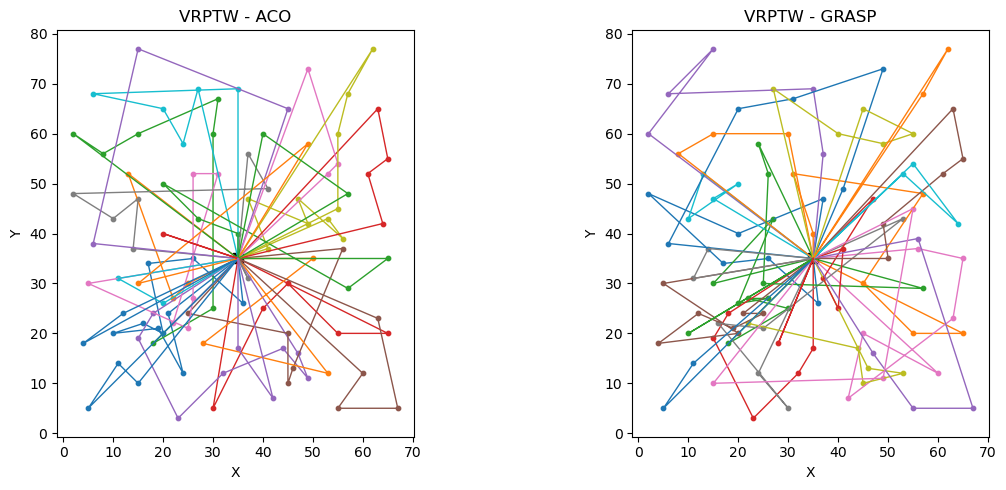

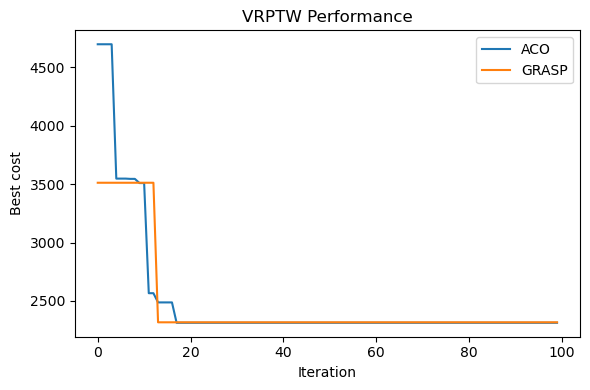

In [59]:
import matplotlib.pyplot as plt

# VRPTW ACO
vrptw_instance = parse_vrptw_input("vrptw.txt")
vrptw_aco_solution, _, vrptw_aco_history = solve_aco_vrptw(
    vrptw_instance, num_ants=30, iterations=100, return_history=True
 )

# VRPTW GRASP
vrptw_grasp_solution, _, vrptw_grasp_history = solve_grasp_vrptw(
    vrptw_instance, iterations=100, alpha=0.3, return_history=True
 )

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_routes(axes[0], vrptw_instance, vrptw_aco_solution, "VRPTW - ACO")
plot_routes(axes[1], vrptw_instance, vrptw_grasp_solution, "VRPTW - GRASP")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(vrptw_aco_history, label="ACO")
ax.plot(vrptw_grasp_history, label="GRASP")
ax.set_title("VRPTW Performance")
ax.set_xlabel("Iteration")
ax.set_ylabel("Best cost")
ax.legend()
plt.tight_layout()
plt.show()

## README (How It Works + Examples)
This section explains the algorithms and shows small, concrete examples of what each step does. The examples are simplified to make the mechanics easy to follow.

---
## 0) What Each Algorithm Does (One-Paragraph Summary)
- **ACO for CVRP**: Builds routes by repeatedly choosing the next customer using pheromone strength (learned good edges) and distance, while respecting capacity. Over many iterations, pheromone updates push ants toward shorter feasible routes.
- **GRASP for CVRP**: Constructs routes using a greedy randomized rule (short distances are preferred but not forced), then improves each route with 2-opt swaps. Repeating this yields better solutions while avoiding poor local minima.
- **ACO for VRPTW**: Similar to CVRP ACO, but also respects time windows. The next-node choice is biased toward customers with tight deadlines (small slack), so routes stay feasible in time.
- **GRASP for VRPTW**: Uses greedy randomized construction with time-window feasibility and urgency scoring, then applies 2-opt only if the swap keeps time windows feasible. This produces valid routes under time constraints.

---
## 1) ACO (Ant Colony Optimization) - Intuition
ACO is a population-based search. Each "ant" builds a complete solution by moving from node to node. Good solutions deposit more pheromone, which increases the probability of choosing those edges later. Over time, ants converge toward shorter routes.

**Key idea**: choose the next node using both **pheromone** (learned good edges) and **heuristic** (short distance or tight deadline).

> **Example (CVRP next-node choice)**
- Suppose an ant is at node 2 and must pick between nodes 5 and 7.
- Distances: $d_{2,5}=10$, $d_{2,7}=20$
- Pheromones: $\tau_{2,5}=2.0$, $\tau_{2,7}=4.0$
- With $\alpha=1$, $\beta=2$:
  - Score(5) $= 2.0 \cdot (1/10)^2 = 0.02$
  - Score(7) $= 4.0 \cdot (1/20)^2 = 0.01$
- Node 5 is twice as likely as node 7 even though node 7 has more pheromone, because it is much farther away.

---
## 2) CVRP ACO (Capacity constraint)
Each route starts at the depot and ends at the depot. While building the route, the ant only considers customers that fit in the remaining capacity.

**Flow**:
1. Start at depot with load = 0
2. Choose a feasible next customer using $\tau^\alpha \cdot \eta^\beta$
3. Update load and repeat until no feasible customers remain
4. Return to depot, start a new route with the remaining customers
5. Compute total distance (cost)
6. Update pheromones, repeat for many iterations

> **Example (capacity feasibility)**
- Vehicle capacity = 10
- Current load = 7
- Candidate customer demand = 4
- 7 + 4 > 10 so this candidate is **not feasible** and cannot be chosen in this route.

---
## 3) VRPTW ACO (Time windows)
VRPTW adds time windows. Vehicles can arrive early and wait, but cannot arrive after the closing time. The heuristic uses **slack** (time remaining until closing).

> **Example (time-window feasibility)**
- Current time = 50
- Travel time to customer = 12 → arrival = 62
- Customer window = [40, 60]
- Arrival (62) is after close (60) → **not feasible**

> **Example (slack heuristic)**
- Customer A: close=100, arrival=60 → slack=40
- Customer B: close=80, arrival=60 → slack=20
- Smaller slack means more urgent, so B is preferred (larger $1/(slack+\epsilon)$).

---
## 4) GRASP - Intuition
GRASP is a two-phase heuristic:
1. **Greedy randomized construction**: build a solution using a Restricted Candidate List (RCL).
2. **Local search**: improve the solution using 2-opt swaps.

**Key idea**: greediness guides the search, randomness prevents getting stuck too early.

> **Example (RCL in construction)**
- Suppose candidate scores are: {A: 10, B: 12, C: 20} (lower is better)
- $c_{min}=10$, $c_{max}=20$, $\alpha=0.3$
- Threshold = $10 + 0.3(20-10)=13$
- RCL = {A, B} (C is excluded because 20 > 13)
- Choose randomly between A and B.

---
## 5) CVRP GRASP
Same GRASP flow, but feasibility checks only capacity. Scoring uses distance only.

**Flow**:
1. Construct routes with capacity checks
2. Apply 2-opt to each route to reduce travel distance
3. Keep the best solution across iterations

> **Example (2-opt swap)**
- Route: 0 → A → B → C → 0
- If reversing segment (A,B,C) reduces distance, the route becomes 0 → C → B → A → 0
- This is accepted if it reduces total cost.

---
## 6) VRPTW GRASP
Same GRASP flow, but feasibility checks **both capacity and time windows**. The score includes slack (urgency) to bias toward customers whose windows close sooner.

**Flow**:
1. Construct routes with capacity + time-window checks
2. 2-opt is allowed only if the new route still respects time windows
3. Keep best solution across iterations

> **Example (2-opt feasibility in VRPTW)**
- A swap might reduce distance but cause a late arrival at a customer.
- In that case, the swap is rejected even if it reduces distance.

---
## 7) Performance plots
The performance curves show the **best cost found so far** at each iteration.
- A steeper drop means fast improvement.
- A flat line means the method is no longer finding better solutions.

---
## 8) Function Guide (Quick Reference)
### ACO Base (shared)
- `build_distance_matrix(instance)`: Build Euclidean distances between all nodes.
- `init_pheromone_matrix(size, initial_value)`: Initialize pheromone grid.
- `evaporate_pheromones(pheromones, evaporation_rate)`: Apply evaporation $\tau \leftarrow (1-\rho)\tau$.
- `deposit_pheromones(pheromones, solution, cost, Q)`: Add $Q/\text{cost}$ along solution edges.
- `construct_solution_cvrp(...)`: Build CVRP routes by feasible selection.
- `select_next_cvrp(...)`: Roulette-wheel choice using pheromone and inverse distance.
- `compute_cost(solution, dist_matrix)`: Total travel distance.

### CVRP ACO
- `parse_cvrp_input(file_path)`: Read CVRP instance file.
- `solve_aco_cvrp(...)`: Run CVRP ACO; can return cost history.

### GRASP Core (shared)
- `greedy_randomised_construction(...)`: Build a solution with RCL.
- `two_opt(route, dist_matrix, feasibility_check)`: Improve route by segment reversal.
- `local_search(...)`: Apply 2-opt to all routes.
- `grasp(...)`: Main GRASP loop with optional history.

### CVRP GRASP
- `cvrp_init_state(...)`: Initialize load.
- `cvrp_update_state(...)`: Update load after visiting a customer.
- `cvrp_feasibility_fn(...)`: Capacity constraint check.
- `cvrp_score_fn(...)`: Distance-only score.
- `solve_grasp_cvrp(...)`: Run GRASP for CVRP.

### VRPTW ACO
- `parse_vrptw_input(file_path)`: Read VRPTW instance file.
- `is_feasible_vrptw(...)`: Capacity + time-window feasibility.
- `select_next_vrptw(...)`: Probability uses slack urgency.
- `construct_solution_vrptw(...)`: Build VRPTW routes with time tracking.
- `solve_aco_vrptw(...)`: Run ACO for VRPTW with penalty if too many vehicles.

### VRPTW GRASP
- `service_start_time(arrival, customer)`: Start time or infeasible (`None`).
- `compute_slack(current_time, travel_time, customer)`: Time-window slack.
- `vrptw_init_state(...)`: Initialize load + time.
- `vrptw_update_state(...)`: Update time + load after a visit.
- `vrptw_feasibility_fn(...)`: Feasibility check for GRASP.
- `vrptw_score_fn(...)`: Distance + slack score.
- `route_time_feasible(...)`: Validate route timing.
- `solve_grasp_vrptw(...)`: Run GRASP for VRPTW.

### Visualizations
- `plot_routes(ax, instance, solution, title)`: Draw depot + routes.
- CVRP/VRPTW visualization cells: plot routes and best-cost curves.